# ARTI 404 — Image Denoising: Spatial vs Frequency Domain
**Assignment:** Image Denoising Using Spatial and Frequency Domain Methods

This notebook implements and evaluates two denoising approaches:
- **Method 1 (Spatial):** Median filtering
- **Method 2 (Frequency):** Gaussian Low-Pass Filter in the frequency domain

Evaluation metrics: **PSNR** and **SSIM**

---

In [2]:
import sys
!{sys.executable} -m pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


In [3]:
import cv2
import numpy as np

print(cv2.__version__)
print(np.__version__)

4.13.0
2.1.3


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# ─────────────────────────────────────────────
# Dataset setup
# ─────────────────────────────────────────────
DATASET = r"C:\Users\janaa\Desktop\Projects\ImageProcessing\dataset"
image_names = [
    "camera",
    "coins",
    "text",
    "rice",
    "astronaut"
]

# ─────────────────────────────────────────────
# Utility: load image
# ─────────────────────────────────────────────
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# ─────────────────────────────────────────────
# Utility: evaluation metrics
# ─────────────────────────────────────────────
def evaluate(clean, denoised):
    psnr_value = psnr(clean, denoised, data_range=255)
    if len(clean.shape) == 3:
        ssim_value = ssim(clean, denoised, channel_axis=-1, data_range=255)
    else:
        ssim_value = ssim(clean, denoised, data_range=255)
    return psnr_value, ssim_value


## Part 1 — Noise Analysis
Visual inspection of each noisy image to identify likely noise type.

PART 1 — NOISE ANALYSIS: Visual Inspection
  camera      : Gaussian noise — smooth continuous random variation over intensity levels
  coins       : Salt-and-pepper noise — isolated bright/dark pixel outliers on dark background
  text        : Salt-and-pepper noise — dense white/black speckle masking the handwritten text
  rice        : Speckle noise — granular multiplicative noise, brighter regions more affected
  astronaut   : Gaussian noise — fine uniform random perturbation across all RGB channels



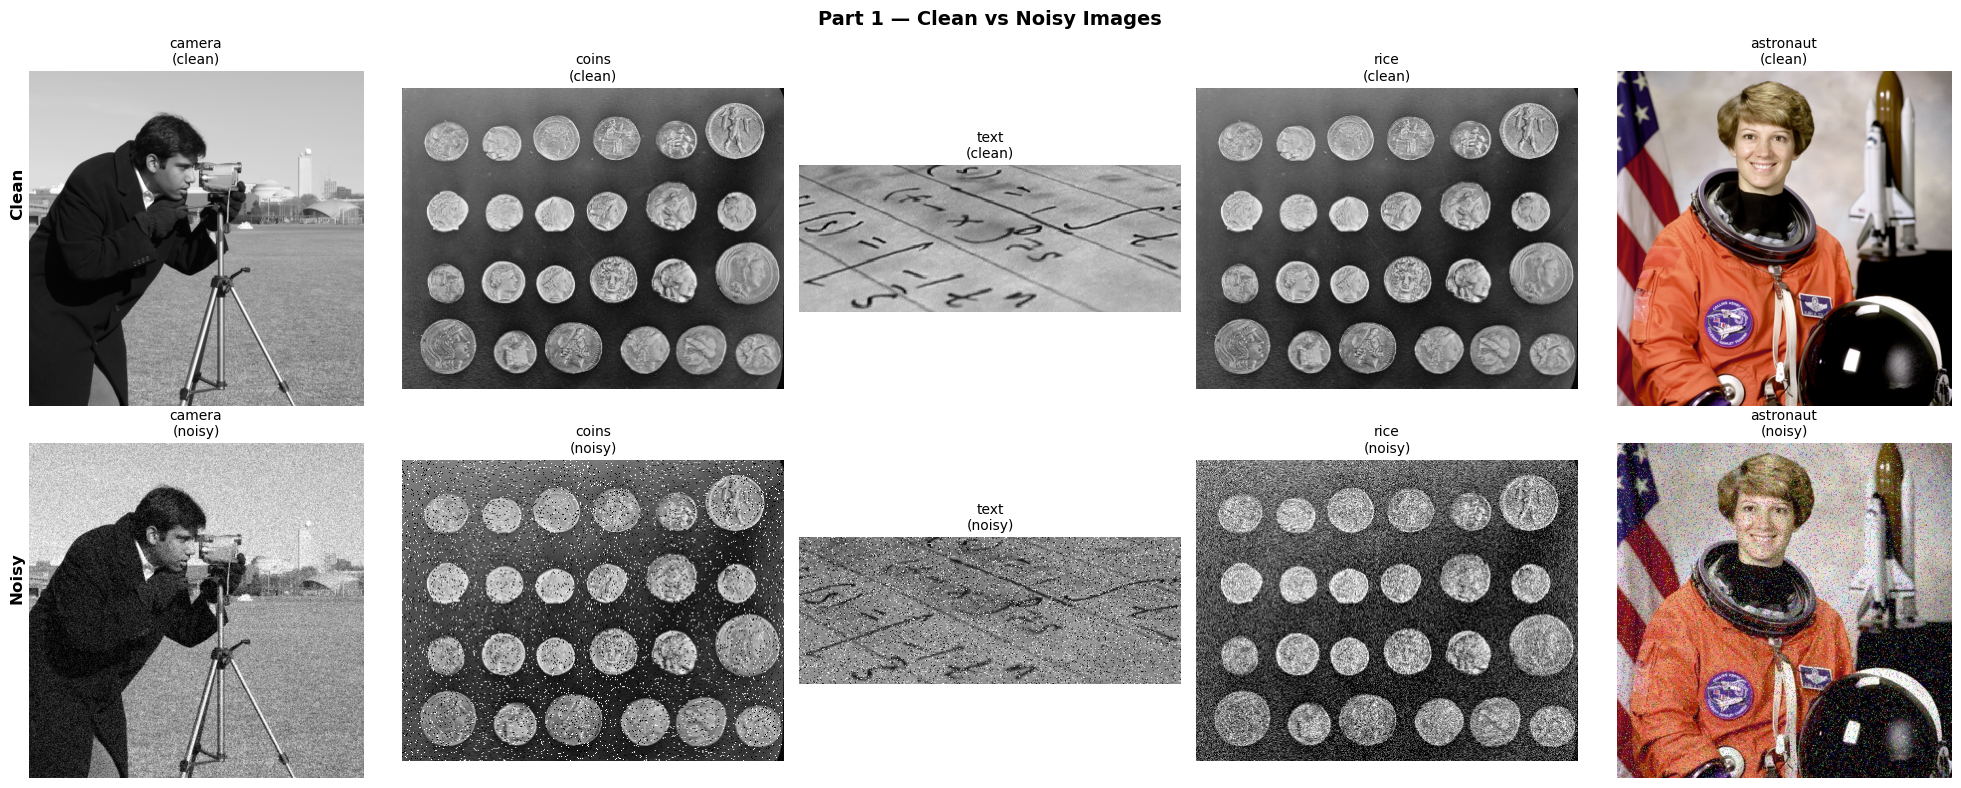

In [6]:
# ═══════════════════════════════════════════════════
# PART 1 — NOISE ANALYSIS
# ═══════════════════════════════════════════════════
# Visual inspection of each noisy image to identify noise type.
# Noise types identified:
#   camera   → Gaussian noise  (continuous fine-grained random variation)
#   coins    → Salt-and-pepper (isolated bright/dark pixel outliers)
#   text     → Salt-and-pepper (heavy white/black speckle on handwriting)
#   rice     → Speckle noise   (granular multiplicative noise pattern)
#   astronaut→ Gaussian noise  (uniform random perturbation on RGB channels)

noise_type_info = {
    "camera":    "Gaussian noise — smooth continuous random variation over intensity levels",
    "coins":     "Salt-and-pepper noise — isolated bright/dark pixel outliers on dark background",
    "text":      "Salt-and-pepper noise — dense white/black speckle masking the handwritten text",
    "rice":      "Speckle noise — granular multiplicative noise, brighter regions more affected",
    "astronaut": "Gaussian noise — fine uniform random perturbation across all RGB channels",
}

print("=" * 65)
print("PART 1 — NOISE ANALYSIS: Visual Inspection")
print("=" * 65)
for name, desc in noise_type_info.items():
    print(f"  {name:12s}: {desc}")
print()

fig, axes = plt.subplots(2, len(image_names), figsize=(20, 8))
for i, name in enumerate(image_names):
    clean_path = os.path.join(DATASET, "clean", f"{name}.png")
    noisy_path = os.path.join(DATASET, "noisy", f"{name}_noisy.png")

    clean = load_image(clean_path)
    noisy = load_image(noisy_path)
    cmap = "gray" if len(clean.shape) == 2 else None

    axes[0, i].imshow(clean, cmap=cmap)
    axes[0, i].set_title(f"{name}\n(clean)", fontsize=10)
    axes[0, i].axis("off")

    axes[1, i].imshow(noisy, cmap=cmap)
    axes[1, i].set_title(f"{name}\n(noisy)", fontsize=10)
    axes[1, i].axis("off")

fig.text(0.01, 0.75, "Clean", va="center", rotation="vertical", fontsize=12, fontweight="bold")
fig.text(0.01, 0.27, "Noisy", va="center", rotation="vertical", fontsize=12, fontweight="bold")
plt.suptitle("Part 1 — Clean vs Noisy Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Part 2 — Denoising Methods
### Method 1: Spatial Domain — Median Filtering
**Justification:** Median filtering is a non-linear rank-order filter robust to impulsive outliers. It eliminates salt-and-pepper noise effectively without blurring edges, unlike mean or Gaussian filters. It also reduces Gaussian and speckle noise, making it the most versatile single spatial method for this mixed-noise dataset.

### Method 2: Frequency Domain — Gaussian Low-Pass Filter
The Gaussian LPF attenuates high-frequency components (where noise typically resides) while preserving low-frequency structure. Applied via: FFT → centre shift → multiply by Gaussian H → inverse shift → IFFT.

In [7]:
# ═══════════════════════════════════════════════════
# PART 2 — DENOISING METHODS
# ═══════════════════════════════════════════════════

# ───────────────────────────────────────────────────
# Method 1: Spatial-Domain — Median Filtering
# ───────────────────────────────────────────────────
# JUSTIFICATION:
# Median filtering replaces each pixel with the median value of its
# local neighbourhood. The median statistic is inherently robust to
# extreme outliers (e.g. salt-and-pepper impulses), which makes it
# highly effective at suppressing impulsive noise without blurring
# edges — a key advantage over mean and Gaussian filters.
# For Gaussian and speckle noise it also performs well by attenuating
# random variation while preserving structural boundaries.
# It is therefore the best single general-purpose choice across the
# variety of noise types present in this dataset.

def spatial_denoising(img, method="median", kernel_size=5):
    """
    Spatial-domain denoising.
    Selected method : Median filtering
    kernel_size     : must be a positive odd integer
    """
    if method == "median":
        return cv2.medianBlur(img, kernel_size)
    elif method == "gaussian":
        return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    elif method == "mean":
        return cv2.blur(img, (kernel_size, kernel_size))
    elif method == "bilateral":
        return cv2.bilateralFilter(img, d=kernel_size, sigmaColor=75, sigmaSpace=75)
    else:
        raise ValueError("Unknown spatial method.")


# ───────────────────────────────────────────────────
# Method 2: Frequency-Domain — Gaussian Low-Pass Filter
# ───────────────────────────────────────────────────
# Steps:
#   1. Compute 2-D Fourier transform of the image.
#   2. Shift zero-frequency component to the centre of the spectrum.
#   3. Construct a Gaussian low-pass filter H in frequency space.
#   4. Multiply the shifted spectrum by H (element-wise).
#   5. Inverse-shift and apply inverse Fourier transform.
#   6. Retain real part and clip to [0, 255].

def gaussian_lowpass_filter(shape, cutoff):
    """
    Construct a 2-D Gaussian low-pass filter.

    Parameters
    ----------
    shape  : (rows, cols) — spatial dimensions of the image
    cutoff : float — Gaussian standard deviation; larger = less smoothing
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    u = np.arange(rows)
    v = np.arange(cols)
    V, U = np.meshgrid(v, u)

    distance_squared = (U - crow) ** 2 + (V - ccol) ** 2
    H = np.exp(-distance_squared / (2 * cutoff ** 2))
    return H


def frequency_gaussian_denoising_gray(img_gray, cutoff=40):
    """Frequency-domain Gaussian LPF for a single grayscale channel."""
    img_float = img_gray.astype(np.float32)

    # Step 1 — Fourier transform
    F = np.fft.fft2(img_float)

    # Step 2 — Shift zero-frequency to centre
    F_shifted = np.fft.fftshift(F)

    # Step 3 — Construct Gaussian LPF
    H = gaussian_lowpass_filter(img_gray.shape, cutoff)

    # Step 4 — Multiply in frequency domain
    G_shifted = F_shifted * H

    # Step 5 — Inverse shift + inverse FFT
    G = np.fft.ifftshift(G_shifted)
    img_filtered = np.fft.ifft2(G)

    # Step 6 — Real part, clip
    img_filtered = np.real(img_filtered)
    return np.clip(img_filtered, 0, 255).astype(np.uint8)


def frequency_gaussian_denoising(img, cutoff=40):
    """
    Frequency-domain Gaussian LPF.
    Handles both grayscale (2-D) and RGB (3-D) images.
    """
    if len(img.shape) == 2:
        return frequency_gaussian_denoising_gray(img, cutoff)
    channels = [frequency_gaussian_denoising_gray(img[:, :, c], cutoff)
                for c in range(img.shape[2])]
    return np.stack(channels, axis=2)


## Part 3 — Parameter Tuning & Part 4 — PSNR / SSIM Evaluation

**PSNR** — measures the ratio of peak signal power to noise power (in dB). **Higher is better.**

**SSIM** — measures perceptual similarity (luminance × contrast × structure). Range [0, 1]. **Higher is better.**

For each method, three parameter settings are tested; the best (by SSIM) is recorded.

In [8]:
# ═══════════════════════════════════════════════════
# PART 3 — PARAMETER TUNING + PART 4 — PSNR / SSIM
# ═══════════════════════════════════════════════════

# ───────────────────────────────────────────────────
# PSNR Explanation
# ───────────────────────────────────────────────────
# PSNR (Peak Signal-to-Noise Ratio) measures the ratio between the
# maximum possible signal power and the power of corrupting noise,
# expressed in decibels (dB). It is computed from the Mean Squared
# Error (MSE) between the clean and denoised images:
#
#   PSNR = 10 · log10(MAX² / MSE)
#
# where MAX = 255 for 8-bit images.
# Higher PSNR → lower MSE → better reconstruction quality.
# A PSNR above ~30 dB is generally considered good quality.

# ───────────────────────────────────────────────────
# SSIM Explanation
# ───────────────────────────────────────────────────
# SSIM (Structural Similarity Index) measures perceptual similarity
# between two images by comparing three components: luminance,
# contrast, and structural information. Values range from 0 to 1.
# Higher SSIM → greater structural/perceptual similarity to the
# clean reference → better denoising quality.
# SSIM is considered more aligned with human visual perception
# than PSNR alone.

# ───────────────────────────────────────────────────
# Parameter settings to test
# ───────────────────────────────────────────────────
spatial_kernel_sizes = [3, 5, 7]    # odd integers only for medianBlur
frequency_cutoffs    = [20, 40, 80] # larger = less smoothing

print("=" * 65)
print("PART 3 & 4 — PARAMETER TUNING + METRIC EVALUATION")
print("=" * 65)

results = []
best_results_store = {}

for name in image_names:
    clean_path = os.path.join(DATASET, "clean", f"{name}.png")
    noisy_path = os.path.join(DATASET, "noisy", f"{name}_noisy.png")

    clean = load_image(clean_path)
    noisy = load_image(noisy_path)

    print(f"\n{'─'*60}")
    print(f"Image: {name}")
    print(f"{'─'*60}")

    # ── Spatial tuning ──
    best_spatial, best_spatial_score = None, -1
    best_spatial_params, best_spatial_metrics = None, None

    for k in spatial_kernel_sizes:
        ds = spatial_denoising(noisy, method="median", kernel_size=k)
        p, s = evaluate(clean, ds)
        marker = " ◄ best" if s > best_spatial_score else ""
        print(f"  [Spatial]  median kernel={k}: PSNR={p:.2f} dB, SSIM={s:.4f}{marker}")
        if s > best_spatial_score:
            best_spatial_score = s
            best_spatial       = ds
            best_spatial_params  = k
            best_spatial_metrics = (p, s)

    # ── Frequency tuning ──
    best_freq, best_freq_score = None, -1
    best_freq_params, best_freq_metrics = None, None

    for cutoff in frequency_cutoffs:
        df = frequency_gaussian_denoising(noisy, cutoff=cutoff)
        p, s = evaluate(clean, df)
        marker = " ◄ best" if s > best_freq_score else ""
        print(f"  [Frequency] Gaussian cutoff={cutoff}: PSNR={p:.2f} dB, SSIM={s:.4f}{marker}")
        if s > best_freq_score:
            best_freq_score  = s
            best_freq        = df
            best_freq_params   = cutoff
            best_freq_metrics  = (p, s)

    results.append([name, "Spatial",
                    f"median, kernel={best_spatial_params}",
                    best_spatial_metrics[0], best_spatial_metrics[1]])
    results.append([name, "Frequency",
                    f"Gaussian LPF, cutoff={best_freq_params}",
                    best_freq_metrics[0], best_freq_metrics[1]])

    best_results_store[name] = (clean, noisy, best_spatial, best_freq,
                                 best_spatial_params, best_freq_params,
                                 best_spatial_metrics, best_freq_metrics)


PART 3 & 4 — PARAMETER TUNING + METRIC EVALUATION

────────────────────────────────────────────────────────────
Image: camera
────────────────────────────────────────────────────────────
  [Spatial]  median kernel=3: PSNR=25.71 dB, SSIM=0.4939 ◄ best
  [Spatial]  median kernel=5: PSNR=26.21 dB, SSIM=0.6040 ◄ best
  [Spatial]  median kernel=7: PSNR=25.48 dB, SSIM=0.6442 ◄ best
  [Frequency] Gaussian cutoff=20: PSNR=22.57 dB, SSIM=0.6268 ◄ best
  [Frequency] Gaussian cutoff=40: PSNR=25.04 dB, SSIM=0.6879 ◄ best
  [Frequency] Gaussian cutoff=80: PSNR=26.94 dB, SSIM=0.6403

────────────────────────────────────────────────────────────
Image: coins
────────────────────────────────────────────────────────────
  [Spatial]  median kernel=3: PSNR=28.07 dB, SSIM=0.8536 ◄ best
  [Spatial]  median kernel=5: PSNR=26.17 dB, SSIM=0.7710
  [Spatial]  median kernel=7: PSNR=25.12 dB, SSIM=0.7262
  [Frequency] Gaussian cutoff=20: PSNR=21.61 dB, SSIM=0.5585 ◄ best
  [Frequency] Gaussian cutoff=40: PSNR=23.

## Part 5 — Results Comparison
Best-parameter results for every image, averages, visual outputs, and bar-chart comparison.


PART 5 — RESULTS TABLE
Image        Method       Best Parameters                 PSNR (dB)       SSIM
------------------------------------------------------------------------------------------
camera       Spatial      median, kernel=7                    25.48     0.6442
camera       Frequency    Gaussian LPF, cutoff=40             25.04     0.6879
coins        Spatial      median, kernel=3                    28.07     0.8536
coins        Frequency    Gaussian LPF, cutoff=40             23.38     0.5748
text         Spatial      median, kernel=3                    32.01     0.9043
text         Frequency    Gaussian LPF, cutoff=20             25.59     0.6524
rice         Spatial      median, kernel=7                    23.34     0.5659
rice         Frequency    Gaussian LPF, cutoff=40             24.14     0.6168
astronaut    Spatial      median, kernel=5                    25.38     0.6887
astronaut    Frequency    Gaussian LPF, cutoff=40             21.93     0.6064
----------------

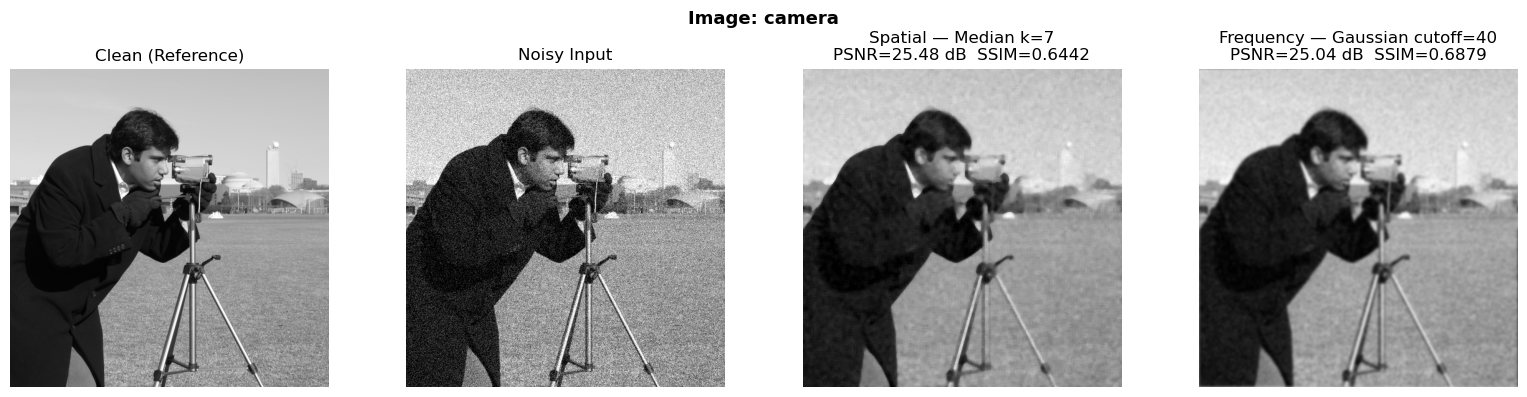

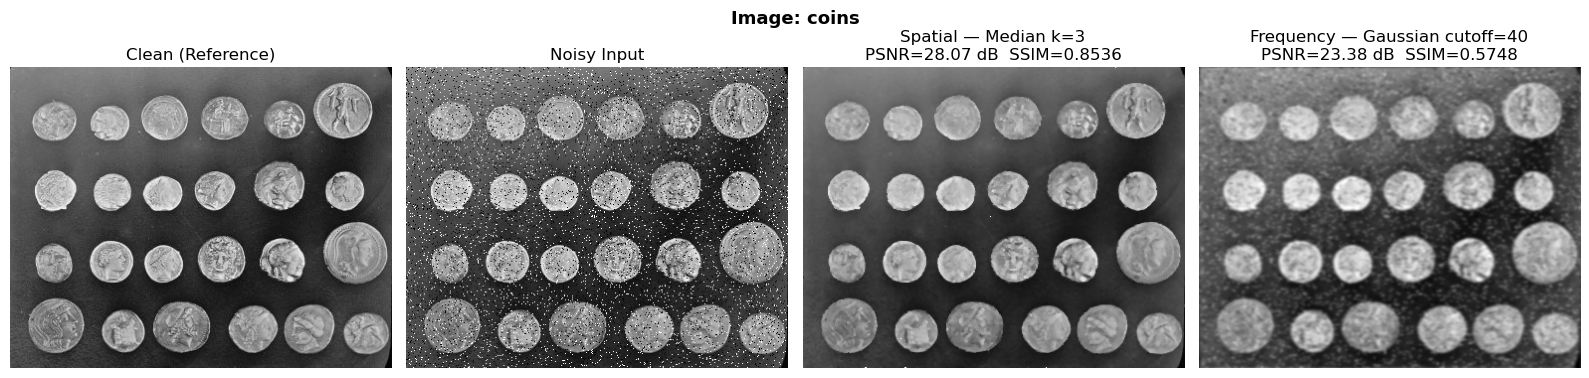

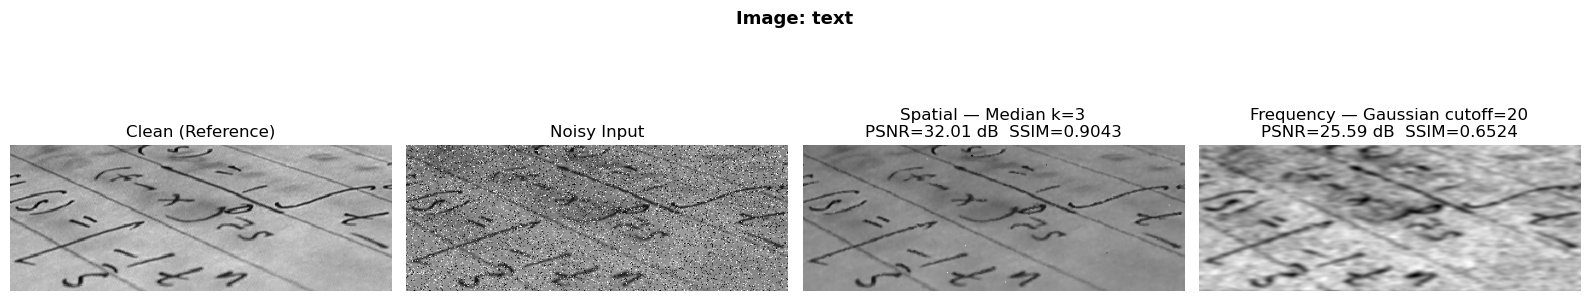

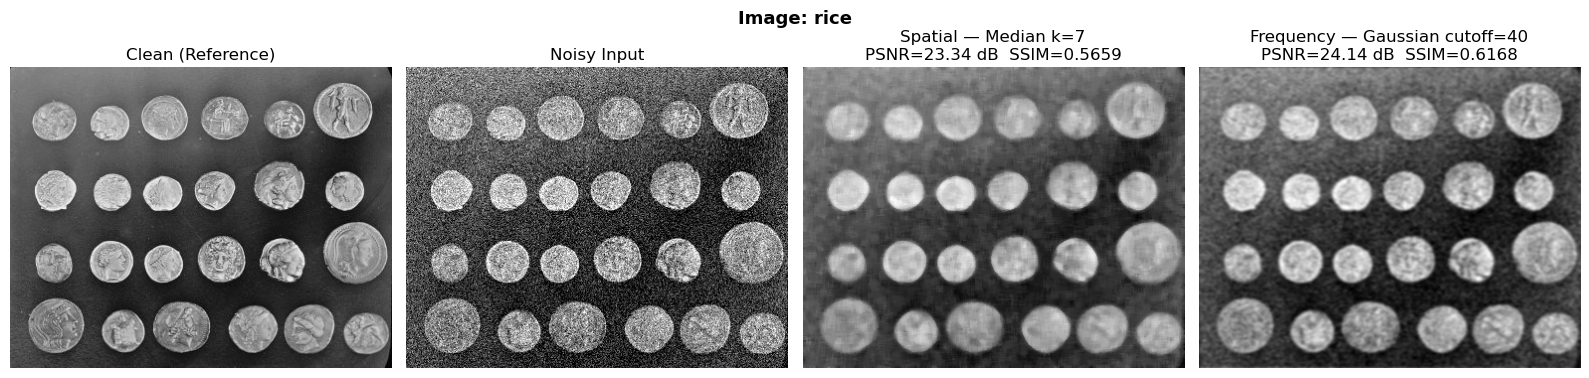

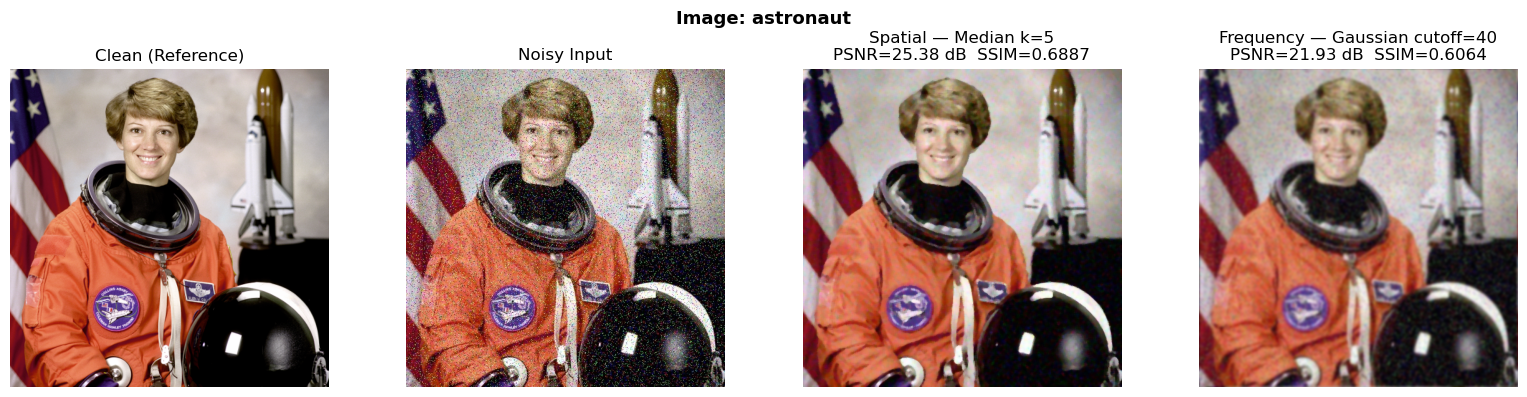

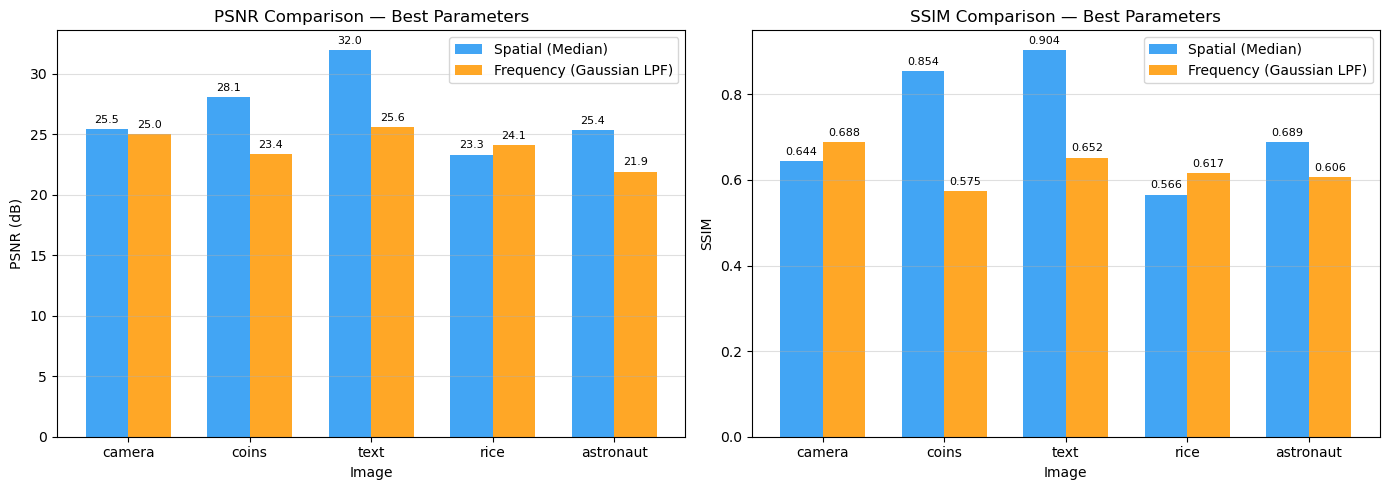


Conclusion:
  Spatial  (Median)       avg PSNR = 26.85 dB,  avg SSIM = 0.7313
  Frequency (Gaussian LPF) avg PSNR = 24.02 dB,  avg SSIM = 0.6276

  ► Median filtering (spatial) outperforms frequency-domain Gaussian LPF
    overall, particularly because several images contain salt-and-pepper
    noise — a type best handled by rank-order (median) filters.


In [9]:
# ═══════════════════════════════════════════════════
# PART 5 — RESULTS COMPARISON
# ═══════════════════════════════════════════════════

# ── Results table ──
print("\n" + "=" * 90)
print("PART 5 — RESULTS TABLE")
print("=" * 90)
print(f"{'Image':12s} {'Method':12s} {'Best Parameters':30s} {'PSNR (dB)':>10s} {'SSIM':>10s}")
print("-" * 90)
for row in results:
    print(f"{row[0]:12s} {row[1]:12s} {row[2]:30s} {row[3]:10.2f} {row[4]:10.4f}")

spatial_psnr = [r[3] for r in results if r[1] == "Spatial"]
spatial_ssim = [r[4] for r in results if r[1] == "Spatial"]
freq_psnr    = [r[3] for r in results if r[1] == "Frequency"]
freq_ssim    = [r[4] for r in results if r[1] == "Frequency"]

print("-" * 90)
print(f"{'AVERAGE':12s} {'Spatial':12s} {'':30s} {np.mean(spatial_psnr):10.2f} {np.mean(spatial_ssim):10.4f}")
print(f"{'AVERAGE':12s} {'Frequency':12s} {'':30s} {np.mean(freq_psnr):10.2f} {np.mean(freq_ssim):10.4f}")
print("=" * 90)

# ── Visual results per image ──
print("\nVisual denoising results:")

for name in image_names:
    clean, noisy, best_spatial, best_freq, k_param, c_param, sm, fm = best_results_store[name]
    cmap = "gray" if len(clean.shape) == 2 else None

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(clean,        cmap=cmap); axes[0].set_title("Clean (Reference)");      axes[0].axis("off")
    axes[1].imshow(noisy,        cmap=cmap); axes[1].set_title("Noisy Input");             axes[1].axis("off")
    axes[2].imshow(best_spatial, cmap=cmap)
    axes[2].set_title(f"Spatial — Median k={k_param}\nPSNR={sm[0]:.2f} dB  SSIM={sm[1]:.4f}")
    axes[2].axis("off")
    axes[3].imshow(best_freq,    cmap=cmap)
    axes[3].set_title(f"Frequency — Gaussian cutoff={c_param}\nPSNR={fm[0]:.2f} dB  SSIM={fm[1]:.4f}")
    axes[3].axis("off")

    plt.suptitle(f"Image: {name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ── Bar-chart comparison ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(image_names))
width = 0.35

sp_psnr = [r[3] for r in results if r[1]=="Spatial"]
fq_psnr = [r[3] for r in results if r[1]=="Frequency"]
sp_ssim = [r[4] for r in results if r[1]=="Spatial"]
fq_ssim = [r[4] for r in results if r[1]=="Frequency"]

b1 = ax1.bar(x - width/2, sp_psnr, width, label="Spatial (Median)",      color="#2196F3", alpha=0.85)
b2 = ax1.bar(x + width/2, fq_psnr, width, label="Frequency (Gaussian LPF)", color="#FF9800", alpha=0.85)
ax1.set_xlabel("Image"); ax1.set_ylabel("PSNR (dB)")
ax1.set_title("PSNR Comparison — Best Parameters")
ax1.set_xticks(x); ax1.set_xticklabels(image_names)
ax1.legend(); ax1.grid(axis="y", alpha=0.4)
ax1.bar_label(b1, fmt="%.1f", padding=3, fontsize=8)
ax1.bar_label(b2, fmt="%.1f", padding=3, fontsize=8)

b3 = ax2.bar(x - width/2, sp_ssim, width, label="Spatial (Median)",         color="#2196F3", alpha=0.85)
b4 = ax2.bar(x + width/2, fq_ssim, width, label="Frequency (Gaussian LPF)", color="#FF9800", alpha=0.85)
ax2.set_xlabel("Image"); ax2.set_ylabel("SSIM")
ax2.set_title("SSIM Comparison — Best Parameters")
ax2.set_xticks(x); ax2.set_xticklabels(image_names)
ax2.legend(); ax2.grid(axis="y", alpha=0.4)
ax2.bar_label(b3, fmt="%.3f", padding=3, fontsize=8)
ax2.bar_label(b4, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

print("\nConclusion:")
print(f"  Spatial  (Median)       avg PSNR = {np.mean(spatial_psnr):.2f} dB,  avg SSIM = {np.mean(spatial_ssim):.4f}")
print(f"  Frequency (Gaussian LPF) avg PSNR = {np.mean(freq_psnr):.2f} dB,  avg SSIM = {np.mean(freq_ssim):.4f}")
print()
if np.mean(spatial_ssim) > np.mean(freq_ssim):
    print("  ► Median filtering (spatial) outperforms frequency-domain Gaussian LPF")
    print("    overall, particularly because several images contain salt-and-pepper")
    print("    noise — a type best handled by rank-order (median) filters.")
else:
    print("  ► Frequency-domain Gaussian LPF outperforms spatial median filtering overall.")
